<a href="https://colab.research.google.com/github/mohammadanwarx/Machine_Learning_Land-Cover_Classification_in_Sudan/blob/main/Big_Geodata_Assignment3_Mo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  # <center>  Big Geodata Processing: Machine Learning Assignment </center>

**course:**  Big Geodata Processing - 202500051
<h4>----------------------------------------------------- </h4>  


**Name:** (MO) Mohamedelmustafa Anwarelsadat Gasmalla  
**Student number:** s3708748
<h4>----------------------------------------------------- </h4>



## Notebook contents:-

This notebook follows a structured workflow to perform supervised land-cover classification over Sudan using Sentinel-2 imagery and machine learning. The analysis is organised into the following tasks:

1. **Define Study Area**  


2. **Collect Image Collection**  
  
3. **Image Reduction and Visualisation**  


4. **Generate Labelled Training Data**  


5. **Train Random Forest Classifier**  


6. **Image Classification**  
  

7. **Evaluate Performance and Generalisation**  
  


### =================================================================
## Project Summary

This project uses a supervised classification workflow in **Sudan** using **Sentinel-2 Surface Reflectance imagery** and a **Random Forest** machine-learning algorithm.

Sudan was the study area for this project and has been identified using a bounding box. Moreover, only the *10 m spatial resolution bands (B2, B3, B4, B8)* for Sentinel were selected and retained to ensure consistency with the spatial resolution.

Training data were generated by **manually** for a mainly five land-cover classes: **Water, Built-up areas, Bare land, Agriculture, and Vegetation**. These polygons were extracted from the GEE interactive map by digitizing it. Then the geometry was captured and written manually to ensure the project's reusability.

Furthermore, it has been converted into labelled `FeatureCollection`, and merged to a single training dataset. The training samples that have been used are more than `500 K`pixels samples.

 samples were **randomly split into training (70%) and validation (30%) subsets** to enable an independent accuracy assessment. A **Random Forest classifier** with 200 trees was trained using the training subset and applied to the Sentinel-2 composite to produce a thematic land-cover map of Sudan.

An accuracy assesment been implemented using **confusion matrix**, The classification achieved an **overall accuracy of approximately `99%`, indicating excellent model accuracy of the selected land-cover classes and strong model generalisation.
###=================================================================

## connect to GEE APIs

In [ ]:
import ee
import geemap

In [ ]:
# # If you are running this notebook for the first time, you need to activate the command below for the authentication flow
ee.Authenticate()


Enter verification code:  4/1ASc3gC20gZXrfmagvdyYl1ezgO1T4vHTj1QShXajOQMFoN7fu5fgmSHTgKQ



Successfully saved authorization token.


In [ ]:
try:
    # Initialize the library.
    ee.Initialize()
    print('Google Earth Engine has initialized successfully!')
except ee.EEException as e:
    print('Google Earth Engine has failed to initialize!')
except:
    print("Unexpected error:", sys.exc_info()[0])
    raise

Google Earth Engine has initialized successfully!


# 1. Define a study area


A study area (ROI) was defined using a bounding-box geometry covering all of **Sudan**, ensuring the study area spans several hundred kilometres and is suitable for large-scale land-cover classification.

BBOX source : https://gist.github.com/graydon/11198540


In [ ]:
Sudan = [(21.93681, 8.61972971293, 38.4100899595, 22.0)] # study area

# 2. Collect Image Collection  
### Image Collection and Preprocessing

A **Sentinel-2 Surface Reflectance** image collection was assembled over the defined study area in Sudan and filtered temporally to the study period and spatially to the region of interest. After applying a cloud-cover threshold, a total of **10,802 images** were retained, ensuring robust temporal coverage and reducing the influence of noise and atmospheric effects.

The image collection was reduced using the **median composite** approach to generate a single representative image for classification. Only **10 m spatial resolution spectral bands (B2 – Blue, B3 – Green, B4 – Red, and B8 – Near Infrared)** were selected, ensuring consistent spatial resolution and suitability for supervised classification.


Data been filtered for;-  
- bounding Box
- the dates : `2025-05-01, 2025-09-30`
- cloud pixel less than `10%`

bands been used = ["B2", "B3", "B4", "B8"]

In [ ]:
# Define AOI (Sudan bounding box)
min_lon, min_lat, max_lon, max_lat = Sudan[0]
geometry = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])

# Load Sentinel-2 Surface Reflectance (Harmonized)
collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(geometry)
    .filterDate("2025-05-01", "2025-09-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
)

# Check collection size
print("Number of images in the collection:", collection.size().getInfo())

# Select ONLY 10 m bands
bands = ["B2", "B3", "B4", "B8"]

# Create median composite (KEEP NAME)
median_image = (
    collection
    .select(bands)
    .median()
    .clip(geometry)
)

# Sanity check
print("Bands in median_image:", median_image.bandNames().getInfo())


Number of images in the collection: 10802
Bands in median_image: ['B2', 'B3', 'B4', 'B8']


# 3. Reduce the image collection
### Image Reduction and Visualisation

The filtered Sentinel-2 image collection was reduced to a single representative image by calculating the **median value** for each pixel across the entire collection. This median composite (`median_image`) effectively minimises the influence of residual clouds, atmospheric noise, and outliers while preserving the dominant spectral characteristics of the study area.

The resulting median image was visualised over the full extent of the study area to verify data quality, spatial coverage, and spectral consistency prior to classification. This visual inspection step ensured that the reduced image accurately represents land-cover patterns across Sudan and is suitable for subsequent training and classification tasks.


Using Folium, the median images collection has been visualized to ensure data reliability.

In [ ]:
import folium

# Define visualization parameters for True Color Composite (B4, B3, B2)
true_color_vis = {
    'min': 0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2'],
}

# Calculate the centroid of the geometry to center the map
centroid = geometry.centroid().coordinates().getInfo()

# Create a Folium map object.
my_map = folium.Map(location=[centroid[1], centroid[0]], zoom_start=6)

# Get a Google Earth Engine tile URL for the True Color image
true_color_map_id = median_image.getMapId(true_color_vis)
true_color_tile_url = true_color_map_id['tile_fetcher'].url_format

# Add the GEE True Color layer to the Folium map.
folium.TileLayer(
    tiles=true_color_tile_url,
    attr='Google Earth Engine',
    name='True Color Composite (Median)',
    overlay=True,
    control=True
).add_to(my_map)

# Add a layer control panel to the map.
my_map.add_child(folium.LayerControl())

# Display the map.
display(my_map)

# 4. Define Training Samples


Labelled training data were created using the **interactive map interface in Google Earth Engine**. Class-specific polygons representing major land-cover types (Water, Built-up areas, Bare land, Agriculture, and Vegetation) were manually digitised across different parts of Sudan. Using polygons rather than individual points allowed each class to capture greater spectral variability and improved the robustness of the training dataset.

The digitised polygons were then **programmatically extracted** from the interactive map environment and converted into Earth Engine geometries. Each polygon was assigned a numeric class label and stored as a reusable `FeatureCollection`. All class-specific collections were subsequently merged into a single labelled dataset, which was used to sample pixel values from the Sentinel-2 median image and generate the final training samples for supervised classification.




In [ ]:
import geemap
from ipyleaflet import DrawControl

Map = geemap.Map()

vis_params = {"min": 0,
              "max": 4000,
              "bands": ["B4", "B3", "B2"]}

Map.centerObject(geometry, 8)
Map.addLayer(median_image, vis_params, "Median Image")

# Create a DrawControl object.
draw_control = DrawControl(
    marker={'shapeOptions': {'color': '#0000FF'}},
    polygon={'shapeOptions': {'color': '#0000FF'}},
    polyline={'shapeOptions': {'color': '#0000FF'}},
    circle={'shapeOptions': {'color': '#0000FF'}},
    rectangle={'shapeOptions': {'color': '#0000FF'}}
)

# Add the DrawControl to the map.
Map.add_control(draw_control)

# Geemap stores drawn features in Map.draw_features
# You can also access them via draw_control.data

display(Map)
print (100* "=")
print("\n this map been used to collect the traning samples")
print("each class been digtized seaprtly ")
print("and then the code blow used to extract it information")
print("")


Map(center=[15.38607841611775, 30.173449979749996], controls=(WidgetControl(options=['position', 'transparent_…


 this map been used to collect the traning samples
each class been digtized seaprtly 
and then the code blow used to extract it information



the below cell retrive the drowing polygon geometry. this method been used per class to  
extract traning samples for the all 5 classes [ Water - Built up - bare land - Agriculture - Vegetation]

In [ ]:

drawn_features = Map.draw_features

if drawn_features:
    # Iterate through each drawn feature
    for ee_feature in drawn_features:
        # Convert the Earth Engine Feature object to a Python dictionary to access its properties.
        feature_dict = ee_feature.getInfo()
        geometry_type = feature_dict['geometry']['type']
        coordinates = feature_dict['geometry']['coordinates']

        print(f"Geometry Type: {geometry_type}")
        print(f"Coordinates: {coordinates}\n")
else:
    print("No geometries have been drawn on the map yet.")


No geometries have been drawn on the map yet.


from above outputs a set of `45` polygons been selected for 5 different classes  
[Water - Built_up - Agriculture - Vegetation]  

this to ensure code reusability and producibility

In [ ]:

# Define the coordinates for each Water as a list of ee.Geometry.Polygon objects
Water = [
    ee.Geometry.Polygon([[[32.070031, 18.842532], [32.070031, 18.854716], [32.079727, 18.854716], [32.079727, 18.842532], [32.070031, 18.842532]]]),
    ee.Geometry.Polygon([[[32.475414, 15.551937], [32.477773, 15.570831], [32.490344, 15.56525], [32.483909, 15.550614], [32.475414, 15.551937]]]),
    ee.Geometry.Polygon([[[32.606359, 15.551855], [32.609641, 15.553147], [32.608043, 15.556785], [32.60699, 15.556878], [32.604501, 15.55725], [32.603536, 15.557581], [32.606359, 15.551855]]]),
    ee.Geometry.Polygon([[[32.746465, 15.406148], [32.742818, 15.410016], [32.737433, 15.411568], [32.736704, 15.410657], [32.737219, 15.409809], [32.741852, 15.407803], [32.746465, 15.406148]]]),
    ee.Geometry.Polygon([[[32.447754, 15.135599], [32.459252, 15.13361], [32.461311, 15.16824], [32.468519, 15.182157], [32.461311, 15.179838], [32.447754, 15.135599]]]),
    ee.Geometry.Polygon([[[37.342452, 21.314964], [37.342452, 21.339269], [37.375403, 21.339269], [37.375403, 21.314964], [37.342452, 21.314964]]]),
    ee.Geometry.Polygon([[[38.309396, 19.342974], [38.309396, 19.348886], [38.323212, 19.348886], [38.323212, 19.342974], [38.309396, 19.342974]]])
]

# Define the coordinates for this new set of Built_up as a list of ee.Geometry.Polygon objects
Built_up = [
    ee.Geometry.Polygon([[[32.525623, 15.642254], [32.525623, 15.643287], [32.529013, 15.643287], [32.529013, 15.642254], [32.525623, 15.642254]]]),
    ee.Geometry.Polygon([[[32.555962, 15.6418], [32.555962, 15.644155], [32.559737, 15.644155], [32.559737, 15.6418], [32.555962, 15.6418]]]),
    ee.Geometry.Polygon([[[32.471421, 15.685787], [32.471357, 15.684299], [32.473287, 15.684278], [32.473159, 15.685848], [32.471421, 15.685787]]]),
    ee.Geometry.Polygon([[[37.210948, 19.603357], [37.210948, 19.604873], [37.213308, 19.604873], [37.213308, 19.603357], [37.210948, 19.603357]]]),
    ee.Geometry.Polygon([[[37.216314, 19.634261], [37.216314, 19.63604], [37.218588, 19.63604], [37.218588, 19.634261], [37.216314, 19.634261]]]),
    ee.Geometry.Polygon([[[37.215801, 19.617122], [37.215801, 19.620397], [37.221035, 19.620397], [37.221035, 19.617122], [37.215801, 19.617122]]])
]


# Define the coordinates for this new set of Bare_Land as a list of ee.Geometry.Polygon objects
Bare_Land = [
    ee.Geometry.Polygon([[[28.389957, 16.028985], [28.389957, 16.03278], [28.394934, 16.03278], [28.394934, 16.028985], [28.389957, 16.028985]]]),
    ee.Geometry.Polygon([[[28.970765, 16.06132], [28.970765, 16.066929], [28.977286, 16.066929], [28.977286, 16.06132], [28.970765, 16.06132]]]),
    ee.Geometry.Polygon([[[32.701408, 15.997058], [32.701408, 16.001678], [32.707157, 16.001678], [32.707157, 15.997058], [32.701408, 15.997058]]]),
    ee.Geometry.Polygon([[[33.137177, 18.212068], [33.137177, 18.222503], [33.151593, 18.222503], [33.151593, 18.212068], [33.137177, 18.212068]]]),
    ee.Geometry.Polygon([[[31.085492, 15.679899], [31.085492, 15.686179], [31.094759, 15.686179], [31.094759, 15.679899], [31.085492, 15.679899]]]),
    ee.Geometry.Polygon([[[31.422514, 15.717412], [31.422514, 15.722204], [31.426118, 15.722204], [31.426118, 15.717412], [31.422514, 15.717412]]]),
    ee.Geometry.Polygon([[[30.001414, 14.772974], [30.001414, 14.776791], [30.006906, 14.776791], [30.006906, 14.772974], [30.001414, 14.772974]]]),
    ee.Geometry.Polygon([[[26.496349, 15.313492], [26.496349, 15.316307], [26.498837, 15.316307], [26.498837, 15.313492], [26.496349, 15.313492]]]),
    ee.Geometry.Polygon([[[26.50656, 15.357777], [26.50656, 15.361005], [26.508619, 15.361005], [26.508619, 15.357777], [26.50656, 15.357777]]]),
    ee.Geometry.Polygon([[[26.458083, 15.361087], [26.458083, 15.363488], [26.460143, 15.363488], [26.460143, 15.361087], [26.458083, 15.361087]]]),
    ee.Geometry.Polygon([[[24.476803, 18.359087], [24.476803, 18.392972], [24.509753, 18.392972], [24.509753, 18.359087], [24.476803, 18.359087]]])
]

# Define the coordinates for this new set of Agriculture as a list of ee.Geometry.Polygon objects
Agriculture = [
    ee.Geometry.Polygon([[[33.027803, 13.093858], [33.023513, 13.11158], [33.03707, 13.115091], [33.039473, 13.10506], [33.027803, 13.093858]]]),
    ee.Geometry.Polygon([[[32.931521, 13.08324], [32.929161, 13.092771], [32.928132, 13.097703], [32.939115, 13.098832], [32.940102, 13.093983], [32.937785, 13.084076], [32.931521, 13.08324]]]),
    ee.Geometry.Polygon([[[32.912849, 13.192276], [32.922674, 13.201969], [32.931856, 13.195493], [32.924605, 13.189351], [32.922803, 13.184588], [32.920786, 13.183084], [32.912849, 13.192276]]]),
    ee.Geometry.Polygon([[[33.055353, 13.17903], [33.052007, 13.184546], [33.047802, 13.182791], [33.044713, 13.183794], [33.039994, 13.181538], [33.037162, 13.177693], [33.041796, 13.171425], [33.055353, 13.17903]]]),
    ee.Geometry.Polygon([[[32.998285, 13.070951], [32.997598, 13.089678], [32.975717, 13.08926], [32.977862, 13.072623], [32.998285, 13.070951]]]),
    ee.Geometry.Polygon([[[33.718004, 13.366344], [33.718004, 13.367116], [33.718455, 13.367116], [33.718455, 13.366344], [33.718004, 13.366344]]]),
    ee.Geometry.Polygon([[[33.705281, 13.369287], [33.705281, 13.370101], [33.706482, 13.370101], [33.706482, 13.369287], [33.705281, 13.369287]]]),
    ee.Geometry.Polygon([[[34.455033, 13.667297], [34.457372, 13.667443], [34.457436, 13.669423], [34.454518, 13.669507], [34.455033, 13.667297]]]),
    ee.Geometry.Polygon([[[34.48621, 13.658664], [34.48473, 13.65977], [34.486446, 13.661563], [34.487133, 13.661417], [34.48621, 13.658664]]]),
    ee.Geometry.Polygon([[[33.927109, 18.234569], [33.924728, 18.234385], [33.924685, 18.235302], [33.926959, 18.235364], [33.927109, 18.234569]]]),
    ee.Geometry.Polygon([[[33.918548, 18.239908], [33.916982, 18.242741], [33.915609, 18.24217], [33.916982, 18.239256], [33.918548, 18.239908]]])
]

# Define the coordinates for this new set of Vegetation as a list of ee.Geometry.Polygon objects
Vegetation = [
    ee.Geometry.Polygon([[[35.111186, 11.281026], [35.111186, 11.283089], [35.115992, 11.283089], [35.115992, 11.281026], [35.111186, 11.281026]]]),
    ee.Geometry.Polygon([[[35.167858, 11.627311], [35.167858, 11.627889], [35.168491, 11.627889], [35.168491, 11.627311], [35.167858, 11.627311]]]),
    ee.Geometry.Polygon([[[30.323606, 10.648419], [30.323606, 10.652932], [30.329441, 10.652932], [30.329441, 10.648419], [30.323606, 10.648419]]]),
    ee.Geometry.Polygon([[[27.312183, 10.327586], [27.312183, 10.327913], [27.312891, 10.327913], [27.312891, 10.327586], [27.312183, 10.327586]]]),
    ee.Geometry.Polygon([[[34.270736, 9.260374], [34.270736, 9.260713], [34.271422, 9.260713], [34.271422, 9.260374], [34.270736, 9.260374]]]),
    ee.Geometry.Polygon([[[34.346248, 9.256647], [34.346248, 9.265457], [34.366842, 9.265457], [34.366842, 9.256647], [34.346248, 9.256647]]]),
    ee.Geometry.Polygon([[[34.263785, 9.093283], [34.263785, 9.095995], [34.265587, 9.095995], [34.265587, 9.093283], [34.263785, 9.093283]]]),
    ee.Geometry.Polygon([[[34.191355, 8.983427], [34.191355, 8.988344], [34.196332, 8.988344], [34.196332, 8.983427], [34.191355, 8.983427]]]),
    ee.Geometry.Polygon([[[34.409882, 8.8464], [34.409882, 8.853864], [34.420522, 8.853864], [34.420522, 8.8464], [34.409882, 8.8464]]]),
    ee.Geometry.Polygon([[[34.410225, 8.718146], [34.410225, 8.727648], [34.419493, 8.727648], [34.419493, 8.718146]]])
]


## 4.1 Visualize traning samples in a map

traning samples been visulized uisng `geemap.Map` object,each class been showed in different color in the map

In [ ]:
import geemap
import ee

# Initialize a geemap Map with OpenStreetMap as the base layer
Map_all_classes = geemap.Map(basemap=geemap.basemaps.OpenStreetMap)

# Define visualization parameters for the median image
vis_params_median = {
    "min": 0,
    "max": 4000,
    "bands": ["B4", "B3", "B2"]
}

# Center the map on the study area (geometry defined earlier)
Map_all_classes.centerObject(geometry, 8)

# Add the median image to the map (above the basemap)
Map_all_classes.addLayer(median_image, vis_params_median, "Median Image")

# Convert the list of Water polygons into an Earth Engine FeatureCollection
water_feature_collection = ee.FeatureCollection(Water)
# Define visualization parameters for the water polygons (blue)
water_vis_params = {'color': '0000FF', 'pointSize': 5, 'width': 2, 'fillColor': '0000FF00'}
# Add the Water polygons to the map
Map_all_classes.addLayer(water_feature_collection, water_vis_params, "Water Polygons")

# Convert the list of Built_up polygons into an Earth Engine FeatureCollection
built_up_feature_collection = ee.FeatureCollection(Built_up)
# Define visualization parameters for the built-up polygons (red)
built_up_vis_params = {'color': 'FF0000', 'pointSize': 5, 'width': 2, 'fillColor': 'FF000000'}
# Add the Built-up polygons to the map
Map_all_classes.addLayer(built_up_feature_collection, built_up_vis_params, "Built-up Polygons")

# Convert the list of Bare_Land polygons into an Earth Engine FeatureCollection
bare_land_feature_collection = ee.FeatureCollection(Bare_Land)
# Define visualization parameters for the bare land polygons (yellow)
bare_land_vis_params = {'color': 'FFFF00', 'pointSize': 5, 'width': 2, 'fillColor': 'FFFF0000'}
# Add the Bare Land polygons to the map
Map_all_classes.addLayer(bare_land_feature_collection, bare_land_vis_params, "Bare Land Polygons")

# Convert the list of Agriculture polygons into an Earth Engine FeatureCollection
agriculture_feature_collection = ee.FeatureCollection(Agriculture)
# Define visualization parameters for the agriculture polygons (orange)
agriculture_vis_params = {'color': 'FFA500', 'pointSize': 5, 'width': 2, 'fillColor': 'FFA50000'}
# Add the Agriculture polygons to the map
Map_all_classes.addLayer(agriculture_feature_collection, agriculture_vis_params, "Agriculture Polygons")

# Convert the list of Vegetation polygons into an Earth Engine FeatureCollection
vegetation_feature_collection = ee.FeatureCollection(Vegetation)
# Define visualization parameters for the vegetation polygons (green)
vegetation_vis_params = {'color': '00FF00', 'pointSize': 5, 'width': 2, 'fillColor': '00FF0000'}
# Add the Vegetation polygons to the map
Map_all_classes.addLayer(vegetation_feature_collection, vegetation_vis_params, "Vegetation Polygons")

# Add a layer control to toggle layers
Map_all_classes.addLayerControl()

# Display the map
display(Map_all_classes)


Map(center=[15.38607841611775, 30.173449979749996], controls=(WidgetControl(options=['position', 'transparent_…

Training samples were generated by extracting pixel values from the Sentinel-2 median image using the labelled training polygons. For each polygon, all intersecting pixels were  at **10 m spatial resolution**, and the  class label was attached to each sample. The resulting dataset consists of pixel-based feature vectors derived from the selected spectral bands and serves as the primary input for training the Random Forest classifier. The total number of extracted samples was inspected to ensure sufficient representation of all land-cover classes.


## 4.2 Spectral Signature Analysis of Training Samples  
in this sub task analysing for the traning samples spectrul signuture been made. to visualize the area of classifying and distinguishing a class from another

to make sure the training samples have their natural spectral reflectance for the earth's surface


In [ ]:
CLASS_IDS = {
    "Water": 0,
    "Built_up": 1,
    "Bare_Land": 2,
    "Agriculture": 3,
    "Vegetation": 4
}
def polygons_to_fc(polygons, class_id):
    return ee.FeatureCollection([
        ee.Feature(geom, {"class": class_id}) for geom in polygons
    ])
water_fc = polygons_to_fc(Water, CLASS_IDS["Water"])
built_fc = polygons_to_fc(Built_up, CLASS_IDS["Built_up"])
bare_fc  = polygons_to_fc(Bare_Land, CLASS_IDS["Bare_Land"])
agri_fc  = polygons_to_fc(Agriculture, CLASS_IDS["Agriculture"])
veg_fc   = polygons_to_fc(Vegetation, CLASS_IDS["Vegetation"])


The class-specific `FeatureCollection`s were merged into a single unified dataset containing all labelled training polygons. This consolidated collection represents the complete ground-truth dataset and serves as the input for sampling pixel values from the Sentinel-2 median image. Merging all classes into one collection is a required step for supervised classification, as it allows the classifier to learn decision


In [ ]:
training_polygons = (
    water_fc
    .merge(built_fc)
    .merge(bare_fc)
    .merge(agri_fc)
    .merge(veg_fc)
)

print("Total training polygons:", training_polygons.size().getInfo())


Total training polygons: 45


the number of polygon which been drawn is `45` and the number of pixle samples is `557.753`

In [ ]:
training_samples = median_image.sampleRegions(
    collection=training_polygons,
    properties=["class"],
    scale=10,
    geometries=False
)


In [ ]:
print("Number of samples:", training_samples.size().getInfo())

Number of samples: 557753


Training samples were generated by extracting pixel values from the Sentinel-2 median image using the labelled training polygons. For each polygon, all intersecting pixels were  at **10 m spatial resolution**, and the  class label was attached to each sample. The resulting dataset consists of pixel-based feature vectors derived from the selected spectral bands and serves as the primary input for training the Random Forest classifier. The total number of extracted samples was inspected to ensure sufficient representation of all land-cover classes.

In [ ]:
# select bands
bands = ["B2", "B3", "B4", "B8"]

class_names = {
    0: "Water",
    1: "Built-up",
    2: "Bare land",
    3: "Agriculture",
    4: "Vegetation"
}

# Grouped median and standard deviation per class
grouped = training_samples.reduceColumns(
    reducer=ee.Reducer.median().repeat(len(bands)).combine(
        reducer2=ee.Reducer.stdDev().repeat(len(bands)),
        sharedInputs=True
    ).group(
        groupField=0,
        groupName="class"
    ),
    selectors=["class"] + bands
).getInfo()


after setting a class index for each classes , The grouped spectral statistics were parsed into a dictionary, where each land-cover class is associated with its median and standard deviation reflectance values. This structure simplifies subsequent visualisation and interpretation of class-wise spectral characteristics.



In [ ]:
spectral_signatures = {}

for g in grouped["groups"]:
    class_id = g["class"]
    # Extract median and stdDev, assuming the order from combine
    spectral_signatures[class_names[class_id]] = {
        "median": g["median"],
        "stdDev": g["stdDev"]
    }


below traning samples spectral signature been Plot, using `seaborn` and `Matplotlib`

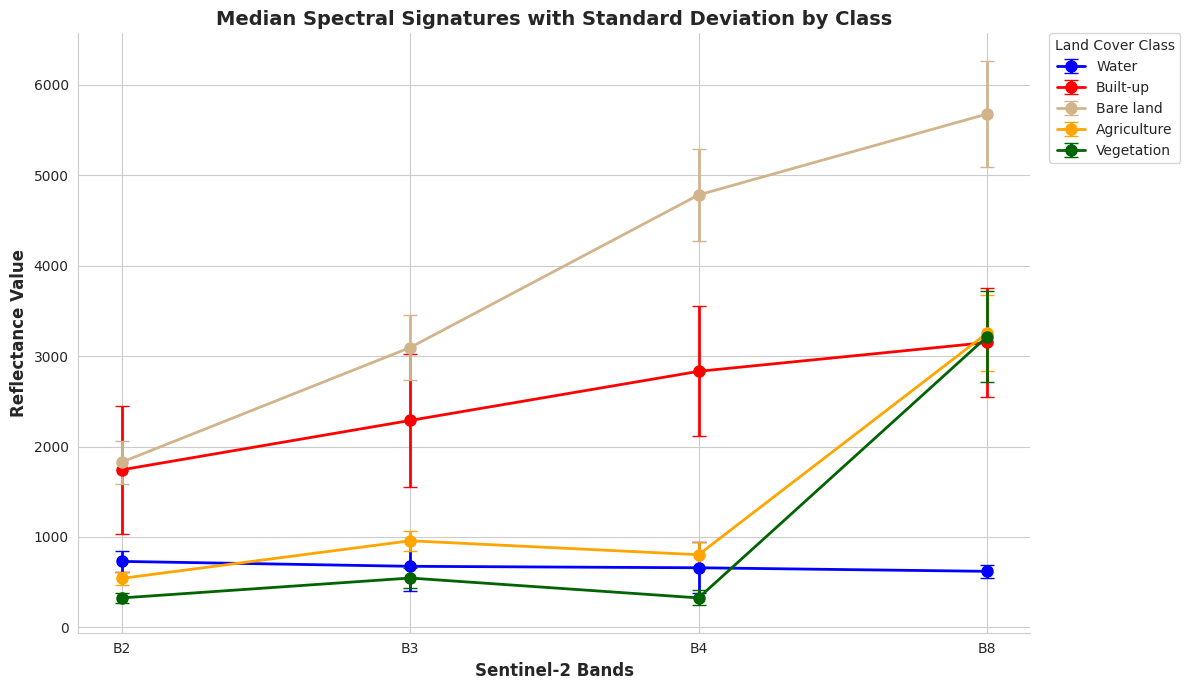

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific colors for each class
class_colors = {
    "Water": "#0000FF",
    "Built-up": "#FF0000",
    "Bare land": "#D2B48C", # Original D2B48C
    "Agriculture": "#FFA500", # Original FFA500
    "Vegetation": "#006400"  # Original 006400
}

# Set a modern seaborn style
sns.set_style("whitegrid") # Options: "darkgrid", "whitegrid", "dark", "white", "ticks"

plt.figure(figsize=(12, 7)) # Increase figure size for better readability

for class_name, data in spectral_signatures.items():
    plt.errorbar(
        bands,
        data["median"],
        yerr=data["stdDev"],
        marker="o",
        capsize=5, # Slightly larger caps for error bars
        linewidth=2, # Make lines a bit thicker
        markersize=8, # Make markers a bit larger
        label=class_name,
        color=class_colors.get(class_name) # Assign color based on class_name
    )

plt.xlabel("Sentinel-2 Bands", fontsize=12, fontweight='bold') # Bold font for labels
plt.ylabel("Reflectance Value", fontsize=12, fontweight='bold')
plt.title("Median Spectral Signatures with Standard Deviation by Class", fontsize=14, fontweight='bold')
plt.legend(title="Land Cover Class", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.) # Adjust legend position for better fit

# Remove top and right spines for a cleaner look
sns.despine()

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Reset to default matplotlib style if needed for subsequent plots
sns.set_style("darkgrid")


## 4.3 Interpretation of Spectral Signatures

- **Water** shows low reflectance across all bands, especially in the near-infrared band (B8), making it clearly distinguishable from other land-cover classes.
- **Bare land** has high reflectance values that increase from visible bands to the near-infrared band, which is typical for exposed soil surfaces.
- **Built-up areas** show moderate to high reflectance in all bands, reflecting the mixed materials commonly found in urban environments.
- **Vegetation** exhibits a strong increase in reflectance in the near-infrared band (B8), which is characteristic of healthy green vegetation.
- **Agriculture** follows a very similar spectral pattern to vegetation, particularly in the near-infrared band.
- The similarity between **agriculture and vegetation** explains the small confusion observed between these two classes in the classification results.
- Larger standard deviation values for agriculture and vegetation indicate higher variability, likely due to differences in crop types, growth stages, and vegetation density.
- Overall, most classes are well separated spectrally, supporting the high classification accuracy achieved by the Random Forest model.


# 5. Train Random Forest Classifier

## 5.1 splitting the training samples

To enable an independent evaluation of model performance, the extracted training samples were randomly partitioned into **training and validation subsets**. A random value was assigned to each sample, and a **70% / 30% split** was applied, with 70% of the samples used for training the classifier and the remaining 30% reserved for validation. This randomised split ensures reproducibility and reduces the risk of overfitting, allowing for a robust assessment of the model’s generalisation capability.


In [ ]:
# Add random number
samples_with_rand = training_samples.randomColumn("random", seed=42)

# 70% training, 30% validation
train_samples = samples_with_rand.filter(ee.Filter.lt("random", 0.7))
valid_samples = samples_with_rand.filter(ee.Filter.gte("random", 0.7))

print("Training samples:", train_samples.size().getInfo())
print("Validation samples:", valid_samples.size().getInfo())


Training samples: 390360
Validation samples: 167393


## 5.2 applying the random forest algorithm

A **Random Forest** classifier was configured and trained using the prepared training samples. The model was built with **200 decision trees**, providing a robust ensemble capable of capturing complex, non-linear relationships between spectral features and land-cover classes. Bootstrap aggregation (bagging) was applied by sampling **70% of the training data** for each tree, which helps reduce overfitting and improve model stability. A fixed random seed was used to ensure reproducibility of the results.

The classifier was trained using the pixel-based training samples, where the **class label** served as the target variable and the selected **Sentinel-2 spectral bands (B2, B3, B4, B8)** were used as input features. The resulting trained model (`trained_rf`) represents the learned relationship between spectral reflectance and land-cover classes and was subsequently used to classify the Sentinel-2 median image.


In [ ]:
rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=200,
    variablesPerSplit=None,
    minLeafPopulation=1,
    bagFraction=0.7,
    seed=42
)


In [ ]:
trained_rf = rf_classifier.train(
    features=train_samples,
    classProperty="class",
    inputProperties=median_image.bandNames()
)


# 6. Image Classification

The trained Random Forest model was applied to the Sentinel-2 median composite to generate a land-cover classification map. Each pixel in the image was assigned a land-cover class based on the spectral patterns learned during the training phase. The resulting classified image represents the spatial distribution of the defined land-cover classes across the entire study area and forms the primary output of the supervised classification process.


In [ ]:
classified_image = median_image.classify(trained_rf)


In [ ]:
# Define colour palette (one colour per class)
class_palette = [
    "0000FF",  # Water
    "FF0000",  # Built-up
    "D2B48C",  # Bare land
    "00FF00",  # Agriculture
    "006400"   # Vegetation
]

Map = geemap.Map(center=[15.5, 30.5], zoom=5)

Map.addLayer(
    classified_image,
    {"min": 0, "max": 4, "palette": class_palette},
    "Random Forest Classification"
)

Map


Map(center=[15.5, 30.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=…

# 7. Evaluate Performance and Generalization  

Model performance was evaluated using an independent validation dataset derived from a random split of the labelled samples. Approximately **70% of the samples were used for training** the Random Forest classifier, while the remaining **30% were reserved for validation**, ensuring an unbiased assessment of model performance.

Classification accuracy was assessed using a **confusion matrix**, overall accuracy, and class-level recall metrics. The results indicate a **high overall accuracy (99%)**, with strong diagonal dominance in the confusion matrix, demonstrating that the model generalises well beyond the training data. Minor confusion observed between agriculture and vegetation is attributed to their similar spectral responses at Sentinel-2’s 10 m spatial resolution. Overall, the evaluation confirms the robustness and generalisation capability of the trained Random Forest model for large-scale land-cover classification over Sudan.


In [ ]:
validated = valid_samples.classify(trained_rf)
confusion_matrix = validated.errorMatrix("class", "classification")
# Get confusion matrix from Earth Engine
cm_info = confusion_matrix.getInfo()

print("Confusion matrix (raw):")
print(cm_info)



Confusion matrix (raw):
[[57782, 0, 0, 0, 0], [0, 1388, 22, 5, 0], [0, 14, 54485, 6, 0], [0, 0, 0, 38301, 81], [0, 0, 0, 360, 14949]]


In [ ]:
print("Overall Accuracy:", 100*(confusion_matrix.accuracy().getInfo()))


Overall Accuracy: 99.70847048562365


## 7.1 plotting Confusion Matrix
Below is the confusion matrix been ploted using `seaborn` and `Matplotlib` showing detailed information about accuracy levels for each class.  
result interpetion is below `\|/`



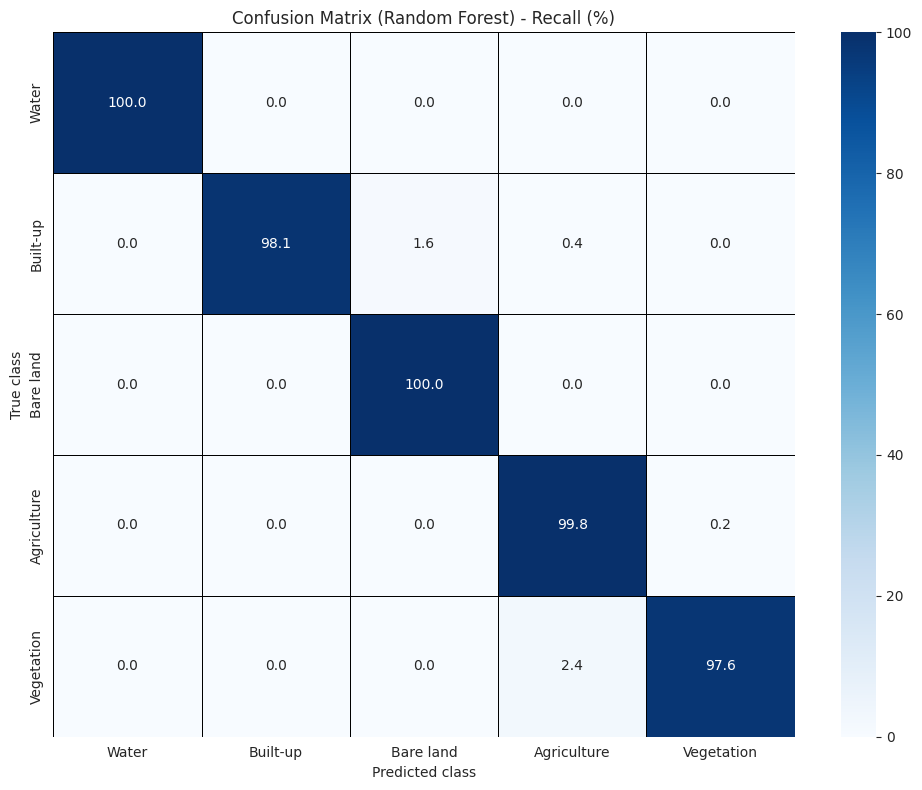

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Convert GEE confusion matrix to NumPy array
cm = np.array(cm_info)

class_names = [
    "Water",
    "Built-up",
    "Bare land",
    "Agriculture",
    "Vegetation"
]

# Calculate percentages (Producer's Accuracy/Recall: true positives / (true positives + false negatives))
# Normalize by row to get percentages of true class being classified correctly
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8)) # Adjust figure size for better readability

sns.heatmap(
    cm_percent,
    annot=True,    # Annotate cells with values
    fmt='.1f',     # Format annotations to one decimal place
    cmap='Blues',  # Use 'Blues' colormap for a gradient effect
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=.5, # Add lines between cells
    linecolor='black'
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix (Random Forest) - Recall (%)")

plt.tight_layout()
plt.show()


## 7.2 **Confusion Matrix Interpretation:**  
The confusion matrix shows very High accuracy percentages, indicating excellent classification performance across all classes. Water and bare land are classified with near-perfect recall, reflecting their distinct spectral signatures in Sentinel-2 imagery. Minor confusion is observed between **agriculture and vegetation**, where a small proportion of vegetation pixels are misclassified as agriculture and vice versa. This confusion is expected, as both classes often exhibit similar spectral characteristics at **10 m spatial resolution**, particularly during the growing season when crop fields and natural vegetation have comparable reflectance patterns. Overall, the results demonstrate strong model generalisation and high classification reliability.


### 7.3 Limitations

Despite the high overall accuracy, the classification results are subject to several limitations. The use of 10 m spatial resolution imagery may not capture fine-scale land-cover heterogeneity, particularly in urban and agricultural areas. Additionally, training labels were derived from visual interpretation, lead to a subjactive ground truth based on my interpetion only. Future work could integrate higher-resolution imagery or multi-seasonal data to further improve class separability.


---

### Author

**Name:** Mo Anwar  
**Email:** m.gasmalla@student.utwente.nl
